First we are going to extract the data from the results file like, we have 145 L sets from 2003 to 2023 for the learning set, and 11 L sets from 2024 to 2025 for the test set.

In [1]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

# ---  Data Extraction and Prep ---
def extract_L_set(filepath):
    l_set = []
    capture = False
    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
            if line.startswith("L set:"):
                capture = True
                continue
            if line.startswith("B vector:"):
                capture = False
                break
            if capture and line.startswith("["):
                row = ast.literal_eval(line)
                l_set.append(row)
    return l_set

# Load data 
train_filePath = '../ED_Calculation/2003_2023/results/finalize_L_set_from_2003_to_2023.txt'
train_data= np.array(extract_L_set(train_filePath))
test_filepath = "../ED_Calculation/2024_current/results/final_result_df_2024_2025.txt"
test_data = np.array(extract_L_set(test_filepath))

Define the splits for train and validation, we need 30 randomly select of validation and rest 115 for training from the learning set.
Each L set represet -> First 5 for the inputs, 6th value is the target.

In [2]:

X_full = train_data[:, :5]
y_full = train_data[:, 5].reshape(-1, 1) # Keep continuous for MSE
X_test = test_data[:, :5]
y_test = test_data[:, 5].reshape(-1, 1)


n_samples = len(X_full)
indices = np.random.permutation(n_samples)
val_indices = indices[:30]
train_indices = indices[30:]

X_train, X_val = X_full[train_indices], X_full[val_indices]
y_train, y_val = y_full[train_indices], y_full[val_indices]


Use the datasets without normalization

In [3]:
# print("Mean per feature:", X_train.mean(axis=0))
# print("Std  per feature:", X_train.std(axis=0))

# Normalize inputs
# mean = X_train.mean(axis=0)
# std = X_train.std(axis=0)
# X_train_n = (X_train - mean) / std
# X_val_n = (X_val - mean) / std
# X_test_n = (X_test - mean) / std

#without normalization
X_train_n = X_train
X_val_n   = X_val
X_test_n  = X_test

Feed-forward Neural Networks parameters. Using Xavier weight initialization. It is a standard method of intialize the weight of nn for sigmoid activation function.
https://en.wikipedia.org/wiki/Weight_initialization

In [4]:

# ---  Network Initialization parameters ---
input_size = 5
hidden_size = 16
output_size = 1
learning_rate = 0.006
epochs = 200


W_h = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / (hidden_size+input_size))
W_o = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / (hidden_size+input_size))
b_o = np.zeros((1, output_size))
B_h = np.random.randn(1, hidden_size) * 0.01

def hidden_sigmoid(x):
    return 1.0 / (1.0 + np.exp( -  x))

def forward(X, w_h, b_h, w_o, b_o):
    H = hidden_sigmoid(X @ w_h + b_h)
    logits = H @ w_o + b_o
    return H, logits

# New Loss and Metric Functions
def mean_squared_error(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)


Training with back-propagation.

In [5]:
# ---  Training Loop ---
epoch_log = []

saved_configs = []
for epoch in range(epochs):
    # Forward pass
    H, logits = forward(X_train_n, W_h, B_h, W_o, b_o)
    
    # Calculate MSE Loss
    loss = mean_squared_error(logits, y_train)
    
    # Backpropagation for MSE
    # Gradient of MSE is: 2 * (y_pred - y_true) / N
    d_logits = 2.0 * (logits - y_train) / X_train_n.shape[0]
    
    dW_o = H.T @ d_logits
    db_o = np.sum(d_logits, axis=0, keepdims=True)
    dH = d_logits @ W_o.T
    dZ_h = dH * ( H * (1 - H))
    dW_h = X_train_n.T @ dZ_h
    dB_h = np.sum(dZ_h, axis=0, keepdims=True)


    # Validation
    _, val_logits = forward(X_val_n, W_h, B_h, W_o, b_o)
    val_loss = mean_squared_error(val_logits, y_val)
    
    # Update Weights
    W_o -= learning_rate * dW_o
    b_o -= learning_rate * db_o
    W_h -= learning_rate * dW_h
    B_h -= learning_rate * dB_h
    

    saved_configs.append({
        'epoch': epoch + 1,
        'W_h': W_h.copy(),
        'B_h': B_h.copy(),
        'W_o': W_o.copy(),
        'b_o': b_o.copy()
    })
    
    epoch_log.append((epoch+1, loss, val_loss))
    
    # print(f"Epoch {epoch+1:3d}/{epochs} _____ Loss: {loss:.4f} -- Val Loss: {val_loss:.4f}")

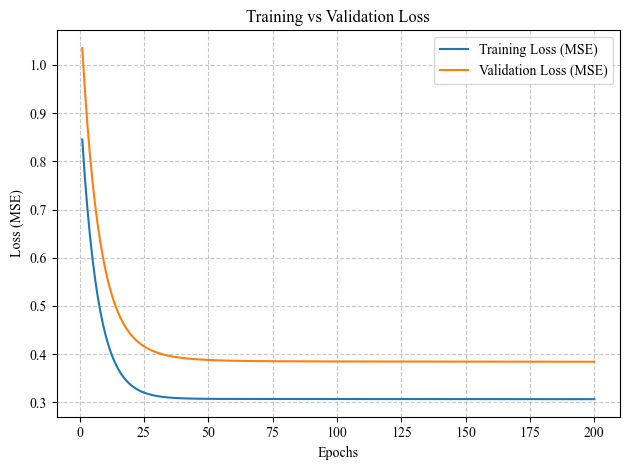

In [6]:

import matplotlib.pyplot as plt
# --- Visualization ---
plt.rcParams['font.family'] = 'Times New Roman'

epochs_list = [entry[0] for entry in epoch_log]
train_loss_list = [entry[1] for entry in epoch_log]
val_loss_list = [entry[2] for entry in epoch_log]
# Subplot 1: MSE Loss
plt.plot(epochs_list, train_loss_list, label='Training Loss (MSE)')
plt.plot(epochs_list, val_loss_list, label='Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)



plt.tight_layout()
plt.show()

In [7]:
#Calculate directional Percentage
def calc_direction_percent(y_true, y_pred):
    correct_direction = ((y_true > 0) & (y_pred > 0)) | ((y_true < 0) & (y_pred < 0))
    total_correct = np.sum(correct_direction)
    return (total_correct / len(y_true)) * 100

best_val_percentage = -1.0
best_config = None
best_val_logits = None

# Evaluate 200 configurations on Validation set
for config in saved_configs:
    _, val_logits = forward(X_val_n, config['W_h'], config['B_h'], config['W_o'], config['b_o'])
    val_percentage = calc_direction_percent(y_val, val_logits)
    
    
    if val_percentage > best_val_percentage:
        best_val_logits = val_logits 
        best_val_percentage = val_percentage
        best_config = config

print(f"Selected Configuration: Epoch {best_config['epoch']}")
# print(f"save configs => {saved_configs[best_config['epoch']]}")
print(f"Biggest Percentage of Correct Price Change (Validation): {best_val_percentage:.2f}%")
    

Selected Configuration: Epoch 38
Biggest Percentage of Correct Price Change (Validation): 66.67%


In [8]:
import pandas as pd
# Create a comparison table
results_df = pd.DataFrame({
    'Actual': y_val.flatten(),
    'Predicted': best_val_logits.flatten(),
    'Direction': (((y_val.flatten() > 0) & (best_val_logits.flatten() > 0)) | ((y_val.flatten() < 0) & (best_val_logits.flatten() < 0))).astype(int)
})

print("Predictions for the 2024-2025 Validation:")
display(results_df)
count_ones = results_df['Direction'].value_counts()[1]
print(results_df['Direction'].value_counts())
print(f"Total right direction => {count_ones}, {(count_ones/len(val_logits.flatten()))*100:.2f}%")

Predictions for the 2024-2025 Validation:


,Actual,Predicted,Direction
0,-1.305160,0.129510,0
1,0.297621,0.178997,1
2,0.375749,0.056451,1
3,0.684954,-0.027563,0
4,0.582000,0.134358,1
5,-0.206083,0.023047,0
6,-0.132598,0.016592,0
7,-0.192841,0.127062,0
8,-0.184005,0.164197,0
9,0.323143,0.003152,1


Direction
1    20
0    10
Name: count, dtype: int64
Total right direction => 20, 66.67%


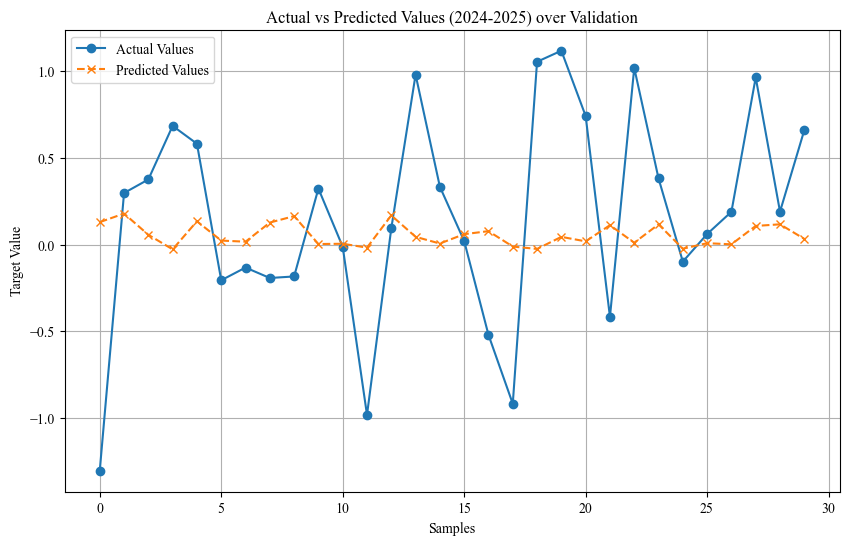

In [9]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_val)), y_val, label="Actual Values", marker="o")
plt.plot(range(len(val_logits)), best_val_logits.flatten(), label="Predicted Values", marker="x", linestyle="--")
plt.title("Actual vs Predicted Values (2024-2025) over Validation")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
_, test_logits = forward(X_test_n, best_config['W_h'], best_config['B_h'], best_config['W_o'], best_config['b_o'])
test_percentage = calc_direction_percent(y_test, test_logits)

In [11]:
import pandas as pd
# Create a comparison table
results_df = pd.DataFrame({
    'Actual': y_test.flatten(),
    'Predicted': test_logits.flatten(),
    'Direction': (((y_test.flatten() > 0) & (test_logits.flatten() > 0)) | ((y_test.flatten() < 0) & (test_logits.flatten() < 0))).astype(int)
})

print("Predictions for the 2024-2025 Test Set:")
display(results_df)
count_ones = results_df['Direction'].value_counts()[1]
print(results_df['Direction'].value_counts())
print(f"Total right direction => {count_ones}, {(count_ones/len(test_logits.flatten()))*100:.2f}%")

Predictions for the 2024-2025 Test Set:


,Actual,Predicted,Direction
0,-0.017473,0.095586,0
1,-0.339443,0.135820,0
2,0.031541,0.061616,1
3,-0.215161,-0.043315,1
4,-0.087107,0.032533,0
5,0.485383,-0.034780,0
6,-0.220254,0.035728,0
7,0.307394,0.042890,1
8,0.306878,0.020578,1
9,0.113420,-0.011434,0


Direction
0    6
1    5
Name: count, dtype: int64
Total right direction => 5, 45.45%


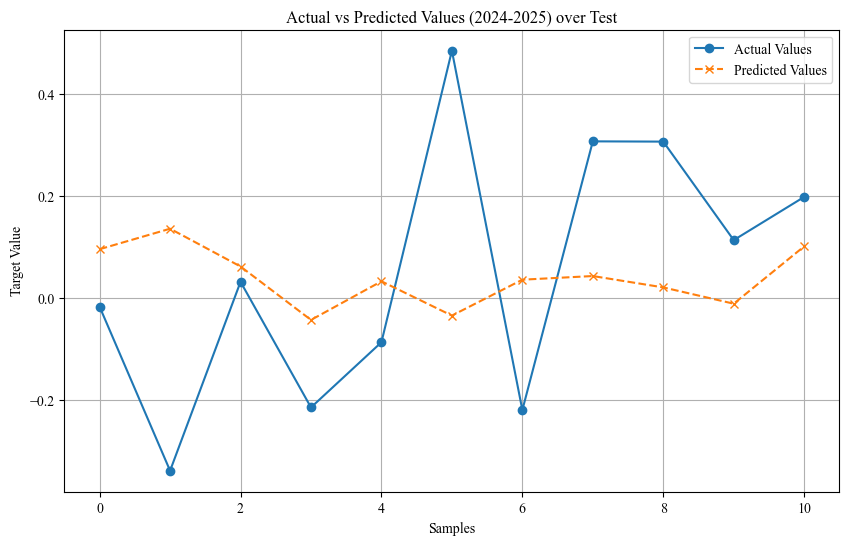

In [12]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test)), y_test, label="Actual Values", marker="o")
plt.plot(range(len(test_logits)), test_logits.flatten(), label="Predicted Values", marker="x", linestyle="--")
plt.title("Actual vs Predicted Values (2024-2025) over Test")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()
